# Titanic — Linear Regression

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold

train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')
print(train.shape, test.shape)
train.head()

(891, 12) (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Фичеинжиниринг

Статистики для заполнения пропусков (медианы возраста по титулу, медиана Fare) считаем **только по train**, чтобы не было утечки.

In [2]:
TITLE_MAP = {
    'Mr': 'Mr', 'Mrs': 'Mrs', 'Miss': 'Miss', 'Master': 'Master',
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
    'Lady': 'Rare', 'Countess': 'Rare', 'Sir': 'Rare', 'Don': 'Rare',
    'Dona': 'Rare', 'Jonkheer': 'Rare', 'Capt': 'Rare', 'Col': 'Rare',
    'Major': 'Rare', 'Dr': 'Rare', 'Rev': 'Rare',
}

def extract_title(df):
    t = df['Name'].str.extract(r',\s*([^\.]+)\.')[0].str.strip()
    return t.map(TITLE_MAP).fillna('Rare')

# Статистики считаем по train
train['Title'] = extract_title(train)
test['Title']  = extract_title(test)

age_by_title = train.groupby('Title')['Age'].median()
fare_median  = train['Fare'].median()
embarked_mode = train['Embarked'].mode()[0]
print('Медиана возраста по титулу:')
print(age_by_title)

Медиана возраста по титулу:
Title
Master     3.5
Miss      21.0
Mr        30.0
Mrs       35.0
Rare      48.5
Name: Age, dtype: float64


In [3]:
def build_features(df):
    df = df.copy()

    # Возраст: заполняем медианой по титулу (не одним средним на всех)
    df['Age'] = df['Age'].fillna(df['Title'].map(age_by_title))
    df['Age'] = df['Age'].fillna(age_by_title.median())

    # Fare: один пропуск в test
    df['Fare'] = df['Fare'].fillna(fare_median)

    # Embarked: заполняем модой
    df['Embarked'] = df['Embarked'].fillna(embarked_mode)

    # Пол → число
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

    # Новые признаки
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    df['FarePerPerson'] = df['Fare'] / df['FamilySize']

    # Категории → one-hot (Title, Embarked, Pclass)
    df = pd.get_dummies(df, columns=['Title', 'Embarked', 'Pclass'], dtype=int)
    return df

train_fe = build_features(train)
test_fe  = build_features(test)

# Выравниваем колонки train и test (одинаковый набор dummy-признаков)
DROP = ['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin']
features = [c for c in train_fe.columns if c not in DROP]
for col in features:
    if col not in test_fe.columns:
        test_fe[col] = 0

print('Признаки:', features)
X = train_fe[features].astype(float)
y = train_fe['Survived'].astype(float)
X_test = test_fe[features].astype(float)
X.head()

Признаки: ['Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Pclass_1', 'Pclass_2', 'Pclass_3']


,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,FarePerPerson,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3
0,0.0,22.0,1.0,0.0,7.2500,2.0,0.0,3.62500,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,1.0,38.0,1.0,0.0,71.2833,2.0,0.0,35.64165,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,1.0,26.0,0.0,0.0,7.9250,1.0,1.0,7.92500,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,1.0,35.0,1.0,0.0,53.1000,2.0,0.0,26.55000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,0.0,35.0,0.0,0.0,8.0500,1.0,1.0,8.05000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


## 2. Обучение + подбор порога (честная CV-оценка)

Линейная регрессия выдаёт число. Через 5-fold кросс-валидацию находим порог, при котором accuracy максимальна.

In [4]:
thresholds = np.arange(0.30, 0.71, 0.01)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# для каждого порога — средняя accuracy по фолдам
acc_by_thr = {t: [] for t in thresholds}

for tr_idx, va_idx in kf.split(X):
    model = LinearRegression()
    model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    pred = model.predict(X.iloc[va_idx])
    y_va = y.iloc[va_idx].values
    for t in thresholds:
        acc = ((pred >= t).astype(int) == y_va).mean()
        acc_by_thr[t].append(acc)

mean_acc = {t: np.mean(v) for t, v in acc_by_thr.items()}
best_thr = max(mean_acc, key=mean_acc.get)
print(f'Лучший порог: {best_thr:.2f}')
print(f'CV accuracy на этом пороге: {mean_acc[best_thr]:.4f}')

Лучший порог: 0.54
CV accuracy на этом пороге: 0.8350


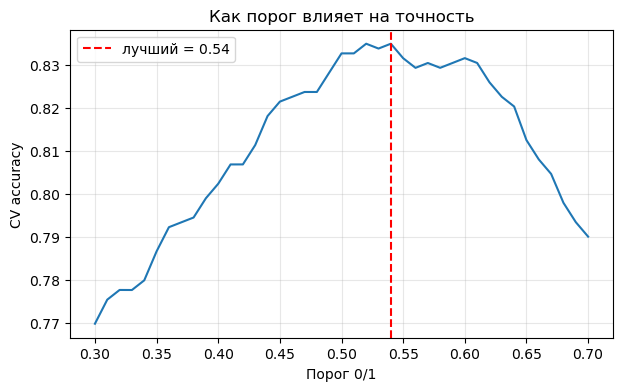

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(list(mean_acc.keys()), list(mean_acc.values()))
plt.axvline(best_thr, color='red', linestyle='--', label=f'лучший = {best_thr:.2f}')
plt.xlabel('Порог 0/1')
plt.ylabel('CV accuracy')
plt.title('Как порог влияет на точность')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 3. Обучаем на всём train и делаем сабмишен

In [6]:
final_model = LinearRegression()
final_model.fit(X, y)

# Как\u0438е признаки тянут вверх/вниз выживаемость
coefs = pd.Series(final_model.coef_, index=features).sort_values()
print(coefs)

Title_Miss      -0.211661
Pclass_3        -0.150618
Title_Mrs       -0.120163
Title_Rare      -0.084693
Title_Mr        -0.062195
IsAlone         -0.055084
FamilySize      -0.047585
Embarked_S      -0.033479
SibSp           -0.032200
Parch           -0.015385
Age             -0.003488
FarePerPerson   -0.000265
Fare             0.000669
Pclass_2         0.005903
Embarked_Q       0.009908
Embarked_C       0.023570
Pclass_1         0.144715
Title_Master     0.478712
Sex              0.670559
dtype: float64


In [7]:
test_pred_num = final_model.predict(X_test)
test_pred = (test_pred_num >= best_thr).astype(int)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': test_pred,
})
submission.to_csv('submission.csv', index=False)
print('submission.csv сохранён:', submission.shape)
print('Доля выживших в предсказании:', test_pred.mean().round(3))
submission.head()

submission.csv сохранён: (418, 2)
Доля выживших в предсказании: 0.383


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
